## 0. Source de dataset
https://www.kaggle.com/datasets/whats2000/human-screaming-detection-dataset

## 1. Placement du token dans Jupyter

In [17]:
import os

# Créer le dossier kaggle
os.makedirs("/home/jovyan/.kaggle", exist_ok=True)

# Colle ici le contenu de ton kaggle.json
kaggle_json = '''{"username":"ahmedmohati","key":"KGAT_9609c29bd5d83ed3afa69fb2043591d2"}'''

with open("/home/jovyan/.kaggle/kaggle.json", "w") as f:
    f.write(kaggle_json)

os.chmod("/home/jovyan/.kaggle/kaggle.json", 0o600)
print("Token Kaggle configuré !")

Token Kaggle configuré !


## 2. Installation et utilisation de l'API Kaggle et téléchargeement de dataset

In [18]:
# Installer l'API Kaggle
os.system("pip install kaggle -q")

# Télécharger le dataset
os.system("kaggle datasets download -d whats2000/human-screaming-detection-dataset -p ./data/")

print("Dataset téléchargé !")

Dataset téléchargé !


## 3. Extraction de dataset

In [20]:
import zipfile

with zipfile.ZipFile("./data/human-screaming-detection-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("./data/SESA")

print("Dataset extrait !")
print(os.listdir("./data/SESA"))

Dataset extrait !
['NotScreaming', 'Screaming']


## 4. Exploration de dataset

In [27]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Voir la structure
for root, dirs, files in os.walk("./data/SESA"):
    level = root.replace("./data/SESA", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = " " * 2 * (level + 1)
        for file in files[:3]:
            print(f"{subindent}{file}")

SESA/
  NotScreaming/
    --PJHxphWEs_out.wav
    -28U1_qW0sU_out.wav
    -4xJv59_zcA_out.wav
  Screaming/
    ---1_cCGK4M_out.wav
    -20uudT97E0_out.wav
    -2yygHLdpXc_out.wav


## 5.  Préparation des données

In [28]:
# Fonction extraction Mel-Spectrogramme
def extract_mel(file_path, max_len=128, n_mels=128, sr=22050):
    try:
        y, sr = librosa.load(file_path, sr=sr, duration=5.0)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        # Taille fixe
        if mel_db.shape[1] < max_len:
            mel_db = np.pad(mel_db, ((0,0),(0, max_len - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :max_len]
        return mel_db
    except Exception as e:
        print(f"Erreur sur {file_path}: {e}")
        return None

# Charger tous les fichiers
X, y_labels = [], []

# Classe 1 = DANGER (cris)
danger_path = "./data/SESA/screaming"
for f in os.listdir(danger_path):
    if f.endswith(".wav") or f.endswith(".mp3"):
        mel = extract_mel(os.path.join(danger_path, f))
        if mel is not None:
            X.append(mel)
            y_labels.append(1)

# Classe 0 = NORMAL
normal_path = "./data/SESA/notScreaming" 
for f in os.listdir(normal_path):
    if f.endswith(".wav") or f.endswith(".mp3"):
        mel = extract_mel(os.path.join(normal_path, f))
        if mel is not None:
            X.append(mel)
            y_labels.append(0)

X = np.array(X)
y_labels = np.array(y_labels)

print(f"Total samples : {len(X)}")
print(f"DANGER  : {sum(y_labels == 1)}")
print(f"NORMAL  : {sum(y_labels == 0)}")

Total samples : 3493
DANGER  : 862
NORMAL  : 2631


## 6. Vérification de l'équilibre des classes

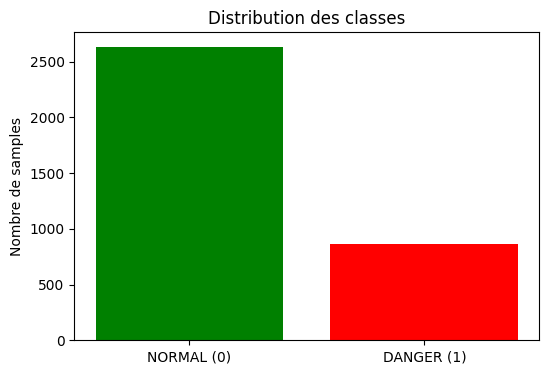

Déséquilibre détecté, rééquilibrage nécessaire


In [22]:
import collections

counter = collections.Counter(y_labels)
plt.figure(figsize=(6,4))
plt.bar(["NORMAL (0)", "DANGER (1)"], [counter[0], counter[1]], 
        color=["green", "red"])
plt.title("Distribution des classes")
plt.ylabel("Nombre de samples")
plt.show()

# Si déséquilibre → on rééquilibre
if abs(counter[0] - counter[1]) > 100:
    print("Déséquilibre détecté, rééquilibrage nécessaire")
else:
    print("Classes équilibrées")

## 7. Undersampling de la classe majoritaire

In [29]:
from sklearn.utils import resample

# Ajouter la dimension canal
X_input = X[..., np.newaxis]

# Séparer les deux classes
X_normal = X_input[y_labels == 0]
X_danger = X_input[y_labels == 1]

# Taille cible = classe minoritaire (862)
min_size = min(len(X_normal), len(X_danger))

# Réduire la classe NORMAL à 862
X_normal_resampled = resample(X_normal, 
                               n_samples=min_size, 
                               random_state=42)

# Recombiner
X_balanced = np.vstack([X_normal_resampled, X_danger])
y_balanced = np.array([0]*min_size + [1]*min_size)

print(f"Après rééquilibrage:")
print(f"NORMAL : {sum(y_balanced == 0)}")
print(f"DANGER : {sum(y_balanced == 1)}")
print(f"Total  : {len(X_balanced)}")

# Mettre à jour les variables
X_input = X_balanced
y_labels = y_balanced

Après rééquilibrage:
NORMAL : 862
DANGER : 862
Total  : 1724


In [9]:
import subprocess
subprocess.run(["pip", "install", "numpy==1.26.4", "--quiet"])

CompletedProcess(args=['pip', 'install', 'numpy==1.26.4', '--quiet'], returncode=0)

## 8. Construction du CNN

In [36]:
from tensorflow.keras import layers, models, regularizers

model = models.Sequential([
    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, (3,3), activation='relu', 
                  padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3,3), activation='relu', 
                  padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    layers.Conv2D(128, (3,3), activation='relu', 
                  padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 128, 128, 32)      320       
                                                                 
 batch_normalization_12 (Ba  (None, 128, 128, 32)      128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 64, 64, 32)        0         
 g2D)                                                            
                                                                 
 dropout_4 (Dropout)         (None, 64, 64, 32)        0         
                                                                 
 conv2d_13 (Conv2D)          (None, 64, 64, 64)        18496     
                                                                 
 batch_normalization_13 (Ba  (None, 64, 64, 64)       

## 9. Entraînement du modèle

In [40]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model.keras", save_best_only=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

Epoch 1/50
87/87 [==============================] - ETA: 0s - loss: 0.8406 - accuracy: 0.5417 - auc: 0.5512
Epoch 1: val_loss improved from inf to 0.86465, saving model to best_model.keras
87/87 [==============================] - 29s 257ms/step - loss: 0.8406 - accuracy: 0.5417 - auc: 0.5512 - val_loss: 0.8647 - val_accuracy: 0.5014 - val_auc: 0.5462 - lr: 0.0010
Epoch 2/50
87/87 [==============================] - ETA: 0s - loss: 0.7671 - accuracy: 0.6222 - auc: 0.6712
Epoch 2: val_loss did not improve from 0.86465
87/87 [==============================] - 21s 246ms/step - loss: 0.7671 - accuracy: 0.6222 - auc: 0.6712 - val_loss: 2.4414 - val_accuracy: 0.4957 - val_auc: 0.5930 - lr: 0.0010
Epoch 3/50
87/87 [==============================] - ETA: 0s - loss: 0.7123 - accuracy: 0.6846 - auc: 0.7403
Epoch 3: val_loss did not improve from 0.86465
87/87 [==============================] - 22s 250ms/step - loss: 0.7123 - accuracy: 0.6846 - auc: 0.7403 - val_loss: 1.0127 - val_accuracy: 0.5014 -

## 10. Évaluation du modèle

11/11 [==============================] - 1s 111ms/step
              precision    recall  f1-score   support

      NORMAL       0.78      0.77      0.78       173
      DANGER       0.78      0.78      0.78       172

    accuracy                           0.78       345
   macro avg       0.78      0.78      0.78       345
weighted avg       0.78      0.78      0.78       345



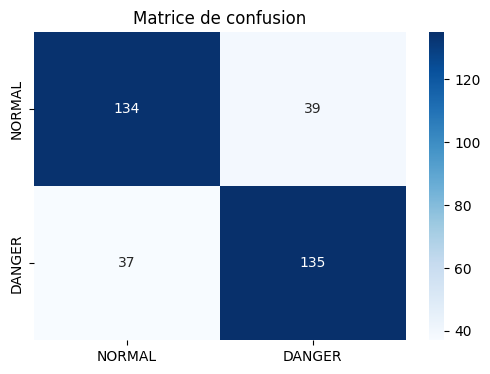

In [41]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Prédictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Rapport
print(classification_report(y_test, y_pred, 
      target_names=["NORMAL", "DANGER"]))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=["NORMAL", "DANGER"],
            yticklabels=["NORMAL", "DANGER"],
            cmap="Blues")
plt.title("Matrice de confusion")
plt.show()

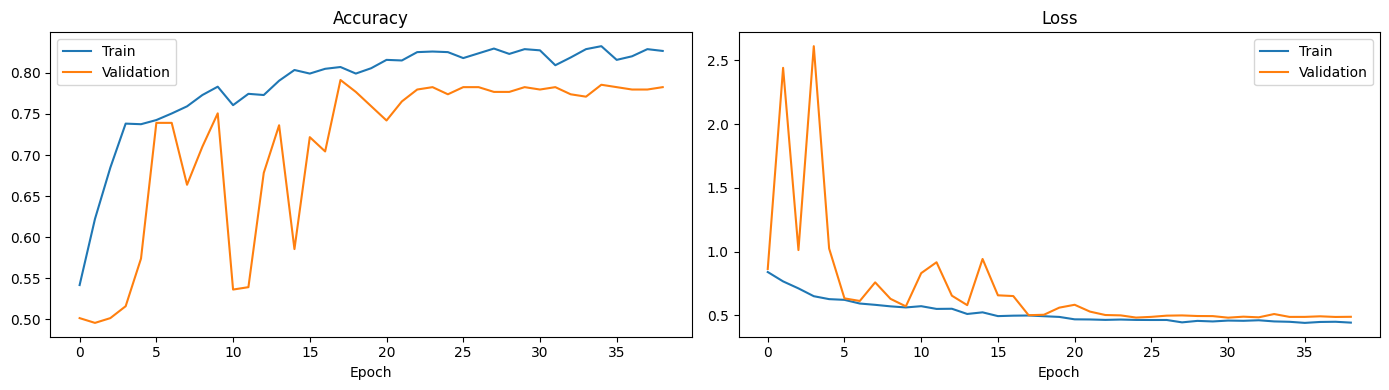

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Conversion en TFLite

In [43]:
import tensorflow as tf

# Convertir avec quantification INT8
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# Sauvegarder
with open("audio_classifier.tflite", "wb") as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"Modèle TFLite sauvegardé !")
print(f"Taille : {size_kb:.1f} KB")

INFO:tensorflow:Assets written to: C:\Users\AHMEDM~1\AppData\Local\Temp\tmplnewynom\assets


INFO:tensorflow:Assets written to: C:\Users\AHMEDM~1\AppData\Local\Temp\tmplnewynom\assets


Modèle TFLite sauvegardé !
Taille : 110.4 KB
